# Session 4 — Solutions

Worked solutions for weights, systematics, fitting, goodness of fit, and limit calculation. Requires processor output (output_2017.pkl or output_2017_full.pkl) from run_analysis.py.

MC histograms from `run_analysis.py --full` are already luminosity-normalised, so do not apply an additional xsec×lumi scaling here.

## Load results and build data / background histograms

In [ ]:
# Session 4 setup: load output bundle, observable templates, and systematics
import sys, os
try:
    sys.setrecursionlimit(8000)
except Exception:
    pass

import pickle
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from scipy.optimize import minimize
from scipy.stats import poisson, chi2

hep.style.use("CMS")

# Ensure project root is importable
for _p in (".", ".."):
    if os.path.isfile(os.path.join(_p, "config", "datasets_2017.py")):
        sys.path.insert(0, os.path.abspath(_p))
        break

from config.datasets_2017 import data_and_bkg_keys


def _load_results_bundle():
    candidates = [
        "output/output_2017.pkl", "output/output_2017_full.pkl",
        "output_2017.pkl", "output_2017_full.pkl",
        "../output/output_2017.pkl", "../output/output_2017_full.pkl",
    ]
    for path in candidates:
        if os.path.isfile(path):
            with open(path, "rb") as f:
                return pickle.load(f)
    raise FileNotFoundError("Run run_analysis.py (or condor merge) first to produce output pickle.")


bundle_or_results = _load_results_bundle()
if isinstance(bundle_or_results, dict) and isinstance(bundle_or_results.get("samples"), dict):
    metadata = bundle_or_results.get("metadata", {})
    results = bundle_or_results["samples"]
else:
    metadata = {}
    results = bundle_or_results


def _unwrap_hist_obj(obj):
    return obj._hist if hasattr(obj, "_hist") else obj


def _pick_observable_and_hist(sample_acc):
    # Prefer SR cos(theta*) if available, else SR recoil.
    hbr = sample_acc.get("hists_by_region", {}) if isinstance(sample_acc, dict) else {}
    if isinstance(hbr, dict):
        cts = _unwrap_hist_obj(hbr.get("cos_theta_star"))
        if cts is not None:
            try:
                return "cos_theta_star", cts[{"region": "sr"}]
            except Exception:
                pass
        recoil = _unwrap_hist_obj(hbr.get("recoil"))
        if recoil is not None:
            try:
                return "recoil", recoil[{"region": "sr"}]
            except Exception:
                pass

    # Legacy flat fallback
    cts = _unwrap_hist_obj(sample_acc.get("cos_theta_star"))
    if cts is not None:
        return "cos_theta_star", cts
    recoil = _unwrap_hist_obj(sample_acc.get("recoil"))
    if recoil is not None:
        return "recoil", recoil
    raise KeyError("No compatible SR observable histogram found (cos_theta_star/recoil).")


def _hist_vals_vars(h):
    vals = np.asarray(h.values(), dtype=float).flatten()
    vars_ = h.variances()
    if vars_ is None:
        vars_ = np.clip(vals, 0.0, None)
    else:
        vars_ = np.clip(np.asarray(vars_, dtype=float).flatten(), 0.0, None)
    edges = np.asarray(h.axes[0].edges, dtype=float)
    return vals, vars_, edges


data_datasets, bkg_datasets = data_and_bkg_keys(results)

# Support both split signal keys (signal_mA...) and unsplit bbDM dataset keys.
def _is_signal_key(k):
    ks = str(k)
    return ks.startswith("signal_") or ks.startswith("bbDM") or ("2HDM" in ks and "bbDM" in ks)

signal_datasets = sorted([k for k in results.keys() if _is_signal_key(k)])
print("Data keys:", data_datasets)
print("Background keys:", bkg_datasets)
print(f"Signal keys ({len(signal_datasets)}):", signal_datasets[:6], "..." if len(signal_datasets) > 6 else "")

# Build observed data histogram and per-process background templates.
obs = None
obs_edges = None
for d in data_datasets:
    if d not in results:
        continue
    obs_name, h = _pick_observable_and_hist(results[d])
    vals, _, edges = _hist_vals_vars(h)
    if obs is None:
        obs = vals.copy()
        obs_edges = edges
        observable_name = obs_name
    else:
        if len(vals) == len(obs):
            obs += vals

bkg_by_process = {}
bkg_var_by_process = {}
for b in bkg_datasets:
    if b not in results:
        continue
    _, h = _pick_observable_and_hist(results[b])
    vals, vars_, edges = _hist_vals_vars(h)
    if obs is not None and len(vals) != len(obs):
        continue
    bkg_by_process[b] = vals
    bkg_var_by_process[b] = vars_

if obs is None:
    if bkg_by_process:
        # fallback if no data available
        first = next(iter(bkg_by_process.values()))
        obs = np.zeros_like(first)
        obs_edges = np.arange(len(first) + 1, dtype=float)
    else:
        obs = np.zeros(10, dtype=float)
        obs_edges = np.arange(11, dtype=float)

bkg = np.sum(np.vstack(list(bkg_by_process.values())), axis=0) if bkg_by_process else np.ones_like(obs)
bkg_stat_var = np.sum(np.vstack(list(bkg_var_by_process.values())), axis=0) if bkg_var_by_process else np.clip(bkg, 0.0, None)

# Signal template: sum available signal samples.
# Some productions have empty SR cos_theta* but non-empty SR recoil (or vice-versa),
# so try both and use the non-empty one that matches the chosen binning.
sig = None
signal_debug = []
for s in signal_datasets:
    sample = results[s]
    hbr = sample.get("hists_by_region", {}) if isinstance(sample, dict) else {}

    cand = []
    if isinstance(hbr, dict):
        h_cts = _unwrap_hist_obj(hbr.get("cos_theta_star"))
        if h_cts is not None:
            try:
                v_cts, _, _ = _hist_vals_vars(h_cts[{"region": "sr"}])
                cand.append(("cos_theta_star", v_cts))
            except Exception:
                pass
        h_rec = _unwrap_hist_obj(hbr.get("recoil"))
        if h_rec is not None:
            try:
                v_rec, _, _ = _hist_vals_vars(h_rec[{"region": "sr"}])
                cand.append(("recoil", v_rec))
            except Exception:
                pass

    # Legacy fallback through helper (if region-aware map is missing)
    if not cand:
        try:
            oname, h = _pick_observable_and_hist(sample)
            v, _, _ = _hist_vals_vars(h)
            cand.append((oname, v))
        except Exception:
            pass

    # Keep candidates compatible with current observable binning
    if obs is not None:
        cand = [(n, v) for (n, v) in cand if len(v) == len(obs)]

    if not cand:
        signal_debug.append((s, "none", 0.0))
        continue

    # Prefer non-zero candidate, otherwise take first compatible one
    cand_sorted = sorted(cand, key=lambda t: float(np.sum(t[1])), reverse=True)
    cname, vals = cand_sorted[0]
    signal_debug.append((s, cname, float(np.sum(vals))))

    if sig is None:
        sig = vals.copy()
    else:
        sig += vals

if sig is None:
    sig = np.zeros_like(bkg)

# Compact debug printout for first few signal samples
for _k, _obsn, _sumv in signal_debug[:8]:
    print(f"  signal debug: {_k} via {_obsn}, sum={_sumv:.4g}")
if len(signal_debug) > 8:
    print(f"  ... {len(signal_debug)-8} more signal samples")

# Read systematics from output metadata (with safe defaults)
sys_cfg = metadata.get("systematics", {}) if isinstance(metadata, dict) else {}
lumi_rel_unc = float(sys_cfg.get("lumi_rel_unc", 0.025))
default_bkg_norm = float(sys_cfg.get("default_bkg_norm_rel_unc", 0.10))
shape_map = sys_cfg.get("shape_rel_unc_by_observable", {}) if isinstance(sys_cfg, dict) else {}
shape_rel_unc = float(shape_map.get(observable_name, 0.05))
proc_map = sys_cfg.get("bkg_norm_rel_unc_by_process", {}) if isinstance(sys_cfg, dict) else {}

# Build per-bin syst variance from process normalization nuisances (uncorrelated by process)
proc_syst_var = np.zeros_like(bkg)
for pname, pvals in bkg_by_process.items():
    rel = float(proc_map.get(pname, default_bkg_norm))
    proc_syst_var += (rel * np.clip(pvals, 0.0, None)) ** 2

lumi_syst_var = (lumi_rel_unc * np.clip(bkg, 0.0, None)) ** 2
shape_syst_var = (shape_rel_unc * np.clip(bkg, 0.0, None)) ** 2

bkg_syst_var = proc_syst_var + lumi_syst_var + shape_syst_var
bkg_total_var = bkg_stat_var + bkg_syst_var
bkg_total_sigma = np.sqrt(np.clip(bkg_total_var, 0.0, None))

# Effective global fractional uncertainty for a simple constrained-nuisance fit model.
frac_unc_eff = float(np.sqrt(np.sum(bkg_syst_var)) / max(np.sum(bkg), 1e-9))

print(f"Observable in SR: {observable_name}")
print(f"Data sum = {obs.sum():.2f}, Bkg sum = {bkg.sum():.2f}, Sig(sum of signal_*) = {sig.sum():.2f}")
print(f"Systematics: lumi={lumi_rel_unc:.3f}, shape({observable_name})={shape_rel_unc:.3f}, eff_global={frac_unc_eff:.3f}")


Data keys: ['data_MET', 'data_SingleElectron']
Background keys: ['DYJets', 'ZJets', 'WJets', 'Top', 'STop', 'DIBOSON', 'SMH']
Signal keys: ['signal_mA600_ma100_mchi1', 'signal_mA600_ma10_mchi1', 'signal_mA600_ma150_mchi1', 'signal_mA600_ma200_mchi1', 'signal_mA600_ma250_mchi1', 'signal_mA600_ma300_mchi1'] ...
Observable in SR: cos_theta_star
Data sum = 70153227.00, Bkg sum = 89579.28, Sig(sum of signal_*) = 0.00
Systematics: lumi=0.025, shape(cos_theta_star)=0.050, eff_global=0.065


## Binned fit (one scale factor for background)

In [2]:
# Background-only fit with one normalization nuisance constrained by systematics
# Model: lambda_i(beta) = beta * bkg_i, with Gaussian prior beta ~ N(1, frac_unc_eff)
# If frac_unc_eff is tiny, keep a minimum to avoid singular fit.
sigma_beta = max(frac_unc_eff, 1e-3)


def nll_bonly(pars):
    beta = float(pars[0])
    lam = np.clip(beta * bkg, 1e-9, None)
    nll_pois = -np.sum(poisson.logpmf(obs.astype(int), lam))
    nll_constr = 0.5 * ((beta - 1.0) / sigma_beta) ** 2
    return nll_pois + nll_constr

fit = minimize(nll_bonly, x0=[1.0], bounds=[(0.01, 5.0)])
beta_best = float(fit.x[0])
expected = beta_best * bkg
expected_sigma = beta_best * bkg_total_sigma

print(f"Best-fit beta = {beta_best:.4f}  (sigma_beta prior = {sigma_beta:.4f})")
print(f"Post-fit expected sum = {expected.sum():.2f} vs observed sum = {obs.sum():.2f}")


Best-fit beta = 5.0000  (sigma_beta prior = 0.0653)
Post-fit expected sum = 447896.41 vs observed sum = 70153227.00


## Goodness of fit

GOF: chi2 = 5713943.85, ndof = 3, p-value = 0.0000


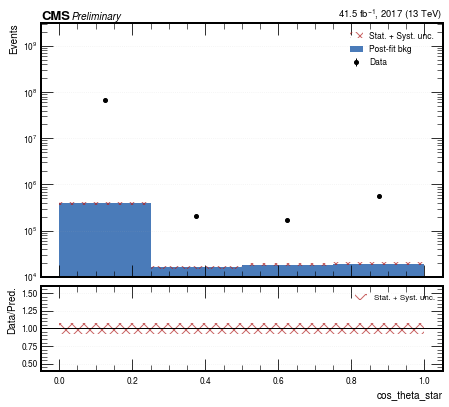

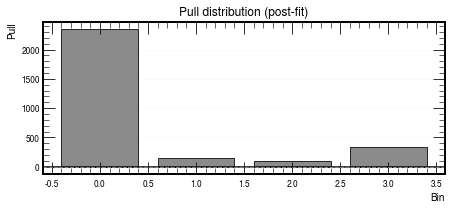

In [3]:
# Goodness-of-fit and CMS-style post-fit plot (main + ratio + pulls)
chi2_val = np.sum((obs - expected) ** 2 / np.clip(expected + expected_sigma**2, 1e-9, None))
ndof = max(len(obs) - 1, 1)
pvalue = 1.0 - chi2.cdf(chi2_val, ndof)
print(f"GOF: chi2 = {chi2_val:.2f}, ndof = {ndof}, p-value = {pvalue:.4f}")

centers = 0.5 * (obs_edges[:-1] + obs_edges[1:])
widths = np.diff(obs_edges)

fig, (ax, rax) = plt.subplots(
    2, 1, sharex=True, figsize=(7.2, 6.4), gridspec_kw={"height_ratios": [3.0, 1.0], "hspace": 0.05}
)

# Main: post-fit background + total unc band + observed points
ax.bar(centers, expected, width=widths, color="#2A64AD", alpha=0.85, edgecolor="none", label="Post-fit bkg")
ax.fill_between(
    obs_edges,
    np.r_[np.clip(expected - expected_sigma, 0.0, None), np.clip(expected - expected_sigma, 0.0, None)[-1]],
    np.r_[expected + expected_sigma, (expected + expected_sigma)[-1]],
    step="post",
    facecolor="none",
    edgecolor="#b22222",
    hatch="xx",
    linewidth=0.0,
    alpha=0.7,
    label="Stat. + Syst. unc.",
)
obs_err = np.sqrt(np.clip(obs, 0.0, None))
ax.errorbar(centers, obs, yerr=obs_err, fmt="o", color="black", markersize=4, linewidth=1.0, label="Data", zorder=10)
ax.set_yscale("log")
ymin, ymax = ax.get_ylim()
ax.set_ylim(max(1e-3, ymin), max(1.0, ymax) * 30.0)
ax.set_ylabel("Events")
hep.cms.label("Preliminary", data=True, lumi=float(metadata.get("lumi_fb", 41.5)), year=int(metadata.get("year", 2017)), ax=ax)
ax.legend(loc="upper right", fontsize=8.5, frameon=False)
ax.grid(alpha=0.18, axis="y")

# Ratio panel: Data/Pred and uncertainty band
ratio = np.divide(obs, expected, out=np.full_like(obs, np.nan, dtype=float), where=expected > 0)
ratio_err = np.divide(obs_err, expected, out=np.full_like(obs_err, np.nan, dtype=float), where=expected > 0)
unc_ratio = np.divide(expected_sigma, expected, out=np.full_like(expected_sigma, np.nan, dtype=float), where=expected > 0)
rax.fill_between(
    obs_edges,
    np.r_[1.0 - unc_ratio, (1.0 - unc_ratio)[-1]],
    np.r_[1.0 + unc_ratio, (1.0 + unc_ratio)[-1]],
    step="post",
    facecolor="none",
    edgecolor="#b22222",
    hatch="xx",
    linewidth=0.0,
    alpha=0.7,
    label="Stat. + Syst. unc.",
)
rax.errorbar(centers, ratio, yerr=ratio_err, fmt="o", color="black", markersize=4, linewidth=1.0)
rax.axhline(1.0, color="black", lw=1.0)
rax.set_ylim(0.4, 1.6)
rax.set_ylabel("Data/Pred.")
rax.set_xlabel(observable_name)
rax.legend(loc="upper right", fontsize=8, frameon=False)
rax.grid(alpha=0.18, axis="y")

# Additional pull plot
pulls = np.divide(obs - expected, np.sqrt(np.clip(expected + expected_sigma**2, 1e-9, None)))
fig2, ax2 = plt.subplots(figsize=(7.2, 2.8))
ax2.bar(np.arange(len(pulls)), pulls, color="#6E6E6E", edgecolor="black", alpha=0.8)
ax2.axhline(0.0, color="black", ls="-")
ax2.axhline(1.0, color="gray", ls="--", lw=1.0)
ax2.axhline(-1.0, color="gray", ls="--", lw=1.0)
ax2.set_xlabel("Bin")
ax2.set_ylabel("Pull")
ax2.set_title("Pull distribution (post-fit)")
ax2.grid(alpha=0.18, axis="y")

plt.show()


## Simple 95% CL upper limit (single bin: total SR yield)

mu_hat = 0.000
Approx. 95% CL upper limit on signal strength mu: nan


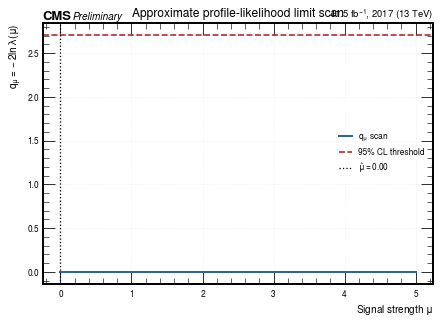

In [4]:
# Approximate 95% CL limit from profile-likelihood scan in signal strength mu
# Model: lambda_i = beta*bkg_i + mu*sig_i, with beta constrained by systematics prior.

sigma_beta = max(frac_unc_eff, 1e-3)


def prof_nll(mu):
    mu = float(mu)

    def nll_beta(beta_arr):
        beta = float(beta_arr[0])
        lam = np.clip(beta * bkg + mu * sig, 1e-9, None)
        nll_p = -np.sum(poisson.logpmf(obs.astype(int), lam))
        nll_c = 0.5 * ((beta - 1.0) / sigma_beta) ** 2
        return nll_p + nll_c

    res = minimize(nll_beta, x0=[beta_best], bounds=[(0.01, 5.0)])
    return float(res.fun), float(res.x[0])

# Global best (mu >= 0)
mu_grid = np.linspace(0.0, 5.0, 101)
scan_vals = []
scan_beta = []
for mu in mu_grid:
    v, bfit = prof_nll(mu)
    scan_vals.append(v)
    scan_beta.append(bfit)
scan_vals = np.asarray(scan_vals, dtype=float)
scan_beta = np.asarray(scan_beta, dtype=float)

imin = int(np.argmin(scan_vals))
mu_hat = float(mu_grid[imin])
nll_min = float(scan_vals[imin])
qmu = 2.0 * (scan_vals - nll_min)

# 95% CL (1 dof approximation): q_mu = 2.71 crossing on the right of mu_hat
target = 2.71
mask = mu_grid >= mu_hat
mu95 = np.nan
if np.any(mask):
    x = mu_grid[mask]
    y = qmu[mask]
    idx = np.where(y >= target)[0]
    if len(idx) > 0:
        j = int(idx[0])
        if j == 0:
            mu95 = float(x[0])
        else:
            x0, x1 = x[j - 1], x[j]
            y0, y1 = y[j - 1], y[j]
            mu95 = float(x0 + (target - y0) * (x1 - x0) / max(y1 - y0, 1e-9))

print(f"mu_hat = {mu_hat:.3f}")
print(f"Approx. 95% CL upper limit on signal strength mu: {mu95:.3f}")

# CMS-like limit scan plot
fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.plot(mu_grid, qmu, color="#2A64AD", lw=2.0, label=r"$q_\mu$ scan")
ax.axhline(2.71, color="#b22222", ls="--", lw=1.6, label="95% CL threshold")
ax.axvline(mu_hat, color="black", ls=":", lw=1.3, label=fr"$\hat{{\mu}}={mu_hat:.2f}$")
if np.isfinite(mu95):
    ax.axvline(mu95, color="#b22222", ls="-.", lw=1.5, label=fr"$\mu_{{95}}={mu95:.2f}$")
ax.set_xlabel(r"Signal strength $\mu$")
ax.set_ylabel(r"$q_\mu = -2\ln\lambda(\mu)$")
ax.set_title("Approximate profile-likelihood limit scan")
hep.cms.label("Preliminary", data=True, lumi=float(metadata.get("lumi_fb", 41.5)), year=int(metadata.get("year", 2017)), ax=ax)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.show()


## Optional solution: Build Combine datacards for all mass points

This uses the helper scripts:

- `scripts/make_combine_datacards.py`
- `output/combine_cards/run_combine_all.sh`
- `scripts/plot_combine_limits.py`

The workflow writes one datacard per available signal mass point in `output/combine_cards` and saves the final plot in `output/combine_plots`.

In [5]:
# Build simple datacards from output pickle and print Combine commands
import os
import subprocess
from pathlib import Path

# Prefer canonical EOS path: /eos/user/<firstletter>/<username>/SWAN_projects/bbdm_cmsdas26
user = os.environ.get("USER", "").strip()
preferred_repo = (
    Path(f"/eos/user/{user[:1]}/{user}/SWAN_projects/bbdm_cmsdas26")
    if user
    else None
)

if preferred_repo is not None and (preferred_repo / "run_analysis.py").exists():
    repo = preferred_repo
else:
    repo = Path.cwd()
    if (repo / "run_analysis.py").exists() is False and (repo.parent / "run_analysis.py").exists():
        repo = repo.parent

print("Using repository:", repo)

pkl_path = repo / "output" / "output_2017_full.pkl"
cards_dir = repo / "output" / "combine_cards"
plots_dir = repo / "output" / "combine_plots"
plots_dir.mkdir(parents=True, exist_ok=True)

if not pkl_path.exists():
    print(f"Missing pickle: {pkl_path}")
    print("Run first: python run_analysis.py --full")
else:
    cmd = [
        "python",
        str(repo / "scripts" / "make_combine_datacards.py"),
        "--input", str(pkl_path),
        "--output-dir", str(cards_dir),
        "--hist-key", "recoil",
        "--region", "sr",
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

    run_all = cards_dir / "run_combine_all.sh"
    print("\nNext commands (in Combine/CMSSW shell):")
    print(f"  bash {run_all}")
    print(
        "  python "
        f"{repo / 'scripts' / 'plot_combine_limits.py'} "
        "--combine-dir "
        f"{cards_dir} "
        "--output "
        f"{plots_dir / 'limits_all_masspoints.png'}"
    )

Using repository: /eos/user/p/ptiwari/SWAN_projects/bbdm_cmsdas26
Running: python /eos/user/p/ptiwari/SWAN_projects/bbdm_cmsdas26/scripts/make_combine_datacards.py --input /eos/user/p/ptiwari/SWAN_projects/bbdm_cmsdas26/output/output_2017_full.pkl --output-dir /eos/user/p/ptiwari/SWAN_projects/bbdm_cmsdas26/output/combine_cards --hist-key recoil --region sr
Wrote 11 datacards.
Combine runner script: /eos/user/p/ptiwari/SWAN_projects/bbdm_cmsdas26/output/combine_cards/run_combine_all.sh

Next commands (in Combine/CMSSW shell):
  bash /eos/user/p/ptiwari/SWAN_projects/bbdm_cmsdas26/output/combine_cards/run_combine_all.sh
  python /eos/user/p/ptiwari/SWAN_projects/bbdm_cmsdas26/scripts/plot_combine_limits.py --combine-dir /eos/user/p/ptiwari/SWAN_projects/bbdm_cmsdas26/output/combine_cards --output /eos/user/p/ptiwari/SWAN_projects/bbdm_cmsdas26/output/combine_plots/limits_all_masspoints.png
